In [39]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import neurokit2 as nk
import spikeinterface.extractors as se
import glob
import os
import h5py
import numpy as np
from scipy.signal import butter, filtfilt, resample_poly
from scipy.signal import find_peaks
from collections import defaultdict
import math
import seaborn as sns

In [2]:
base_dir = r"D:\BLA_ChR_resp"

BORIS_DIRS = [
    "RI1_day1_boris",
    "RI1_day2_boris",
    "RI2_day1_boris_post",
    "RI2_day2_boris_post"
]

files = []

for folder in BORIS_DIRS:
    full_path = os.path.join(base_dir, folder)
    csvs = glob.glob(os.path.join(full_path, "*.csv"))
    files.extend(csvs)

# Exclude social-agent scoring
files = [f for f in files if not f.endswith("_sa.csv")]

print("Total BORIS files:", len(files))

Total BORIS files: 94


In [ ]:
# def load_boris_for_inspection(csv_path):
#     df = pd.read_csv(csv_path)

#     # --- Standardize timing column names ---
#     df = df.rename(columns={
#         "Start (s)": "Start",
#         "Stop (s)": "Stop",
#         "Duration (s)": "Duration"
#     })

#     # --- Keep only columns needed to LOOK at behavior ---
#     keep_cols = [
#         "Behavior",
#         "Behavior type",
#         "Subject",              # BORIS role: subject / agent
#         "Start",
#         "Stop",
#         "Duration",
#         "FPS (frame/s)",
#         "Image index start",
#         "Image index stop",
#         "Media file name"
#     ]
#     keep_cols = [c for c in keep_cols if c in df.columns]
#     df = df[keep_cols].copy()

#     # --- Light cleaning ---
#     df["Behavior"] = df["Behavior"].astype(str).str.strip().str.lower()
#     df["Subject"] = df["Subject"].astype(str).str.strip().str.lower()

#     # ============================
#     # ADD METADATA FROM FILENAME
#     # ============================
#     fname = os.path.basename(csv_path)
#     parts = fname.replace(".csv", "").split("_")

#     # Subject ID = cage_mouse (e.g. 1_2)
#     cage = parts[0]
#     mouse = parts[1]
#     subject_id = f"{cage}_{mouse}"

#     # Laser condition
#     laser = "ON" if "on" in parts else "OFF"

#     df["SubjectID"] = subject_id
#     df["Laser"] = laser

#     return df


In [3]:
def load_boris_for_inspection(csv_path):
    df = pd.read_csv(csv_path)

    # --- Standardize timing column names ---
    df = df.rename(columns={
        "Start (s)": "Start",
        "Stop (s)": "Stop",
        "Duration (s)": "Duration"
    })

    # --- Keep only relevant columns ---
    keep_cols = [
        "Behavior",
        "Behavior type",
        "Subject",
        "Start",
        "Stop",
        "Duration",
        "FPS (frame/s)",
        "Image index start",
        "Image index stop",
        "Media file name"
    ]
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols].copy()

    # --- Light cleaning ---
    df["Behavior"] = df["Behavior"].astype(str).str.strip().str.lower()
    df["Subject"] = df["Subject"].astype(str).str.strip().str.lower()

    # ============================
    # ADD METADATA FROM FILENAME
    # ============================

    fname = os.path.basename(csv_path)
    parts = fname.replace(".csv", "").split("_")

    # Subject ID
    cage = parts[0]
    mouse = parts[1]
    subject_id = f"{cage}_{mouse}"

    # Condition (RI1 / RI2)
    if "RI1" in parts:
        condition = "RI1"
    elif "RI2" in parts:
        condition = "RI2"
    else:
        condition = "UNKNOWN"

    # Laser condition
    laser = "ON" if "on" in parts else "OFF"

    df["SubjectID"] = subject_id
    df["Condition"] = condition
    df["Laser"] = laser

    return df

In [4]:
dfs = []
for f in files:
    df = load_boris_for_inspection(f)
    df["File"] = os.path.basename(f)
    dfs.append(df)

boris_df = pd.concat(dfs, ignore_index=True)



In [5]:
HISTO_FAIL = ["1_3", "3_3"]  # update as histology completes

boris_df = boris_df[
    ~boris_df["SubjectID"].isin(HISTO_FAIL)
].copy()

print("After histology exclusion:", boris_df["SubjectID"].nunique())

After histology exclusion: 22


In [6]:
boris_df = boris_df.copy()

# Extract cage number from SubjectID (e.g. "3_2" → 3)
boris_df["Cage"] = boris_df["SubjectID"].str.split("_").str[0].astype(int)

# Assign group
boris_df["Group"] = boris_df["Cage"].apply(
    lambda x: "GFP" if x % 2 == 0 else "ChR-YFP"
)


In [7]:
boris_df.columns


Index(['Behavior', 'Behavior type', 'Subject', 'Start', 'Stop', 'Duration',
       'FPS (frame/s)', 'Image index start', 'Image index stop',
       'Media file name', 'SubjectID', 'Condition', 'Laser', 'File', 'Cage',
       'Group'],
      dtype='object')

In [8]:
boris_df.shape
boris_df.head()


,Behavior,Behavior type,Subject,Start,Stop,Duration,FPS (frame/s),Image index start,Image index stop,Media file name,SubjectID,Condition,Laser,File,Cage,Group
0,facial sniffing,STATE,subject,60.938,62.437,1.499,16.0,975.0,NaN,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,RI1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
1,anogenital sniffing,STATE,subject,62.438,64.938,2.500,16.0,999.0,1039.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,RI1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
2,chasing,STATE,subject,65.375,67.062,1.687,16.0,1046.0,1073.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,RI1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
3,anogenital sniffing,STATE,subject,67.438,68.437,0.999,16.0,1079.0,NaN,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,RI1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
4,body sniffing,STATE,subject,68.438,71.062,2.624,16.0,1095.0,1137.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,RI1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP


In [9]:
boris_df

,Behavior,Behavior type,Subject,Start,Stop,Duration,FPS (frame/s),Image index start,Image index stop,Media file name,SubjectID,Condition,Laser,File,Cage,Group
0,facial sniffing,STATE,subject,60.938,62.437,1.499,16.0,975.0,NaN,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,RI1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
1,anogenital sniffing,STATE,subject,62.438,64.938,2.500,16.0,999.0,1039.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,RI1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
2,chasing,STATE,subject,65.375,67.062,1.687,16.0,1046.0,1073.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,RI1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
3,anogenital sniffing,STATE,subject,67.438,68.437,0.999,16.0,1079.0,NaN,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,RI1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
4,body sniffing,STATE,subject,68.438,71.062,2.624,16.0,1095.0,1137.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,RI1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3232,facial sniffing,STATE,social_agent,217.688,218.375,0.687,16.0,3484.0,3495.0,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/...,9_1,RI2,ON,9_1_RI2_m2_p_on_20260120_125329.1_BORIS_FINAL.csv,9,ChR-YFP
3233,facial sniffing,STATE,subject,217.750,218.375,0.625,16.0,3485.0,3495.0,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/...,9_1,RI2,ON,9_1_RI2_m2_p_on_20260120_125329.1_BORIS_FINAL.csv,9,ChR-YFP
3234,facial sniffing,STATE,subject,222.062,222.500,0.438,16.0,3554.0,3561.0,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/...,9_1,RI2,ON,9_1_RI2_m2_p_on_20260120_125329.1_BORIS_FINAL.csv,9,ChR-YFP
3235,facial sniffing,STATE,social_agent,222.500,223.438,0.938,16.0,3561.0,3576.0,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/...,9_1,RI2,ON,9_1_RI2_m2_p_on_20260120_125329.1_BORIS_FINAL.csv,9,ChR-YFP


In [10]:
bout_counts = (
    boris_df
    .groupby(["SubjectID", "Group", "Laser", "Behavior", "Condition"], as_index=False)
    .size()
    .rename(columns={"size": "BoutCount"})
)


In [11]:
bout_counts


,SubjectID,Group,Laser,Behavior,Condition,BoutCount
0,1_1,ChR-YFP,OFF,anogenital sniffing,RI1,13
1,1_1,ChR-YFP,OFF,body sniffing,RI1,6
2,1_1,ChR-YFP,OFF,chasing,RI1,2
3,1_1,ChR-YFP,OFF,facial sniffing,RI1,8
4,1_1,ChR-YFP,OFF,facial sniffing,RI2,2
...,...,...,...,...,...,...
316,9_1,ChR-YFP,ON,body sniffing,RI1,15
317,9_1,ChR-YFP,ON,body sniffing,RI2,6
318,9_1,ChR-YFP,ON,facial sniffing,RI1,24
319,9_1,ChR-YFP,ON,facial sniffing,RI2,14


In [12]:
paired = (
    bout_counts
    .groupby(["SubjectID", "Group", "Condition", "Behavior"])["Laser"]
    .nunique()
    .reset_index()
)

paired = paired[paired["Laser"] == 2]  # must have ON + OFF within condition

bout_counts_paired = bout_counts.merge(
    paired[["SubjectID", "Group", "Condition", "Behavior"]],
    on=["SubjectID", "Group", "Condition", "Behavior"],
    how="inner"
)


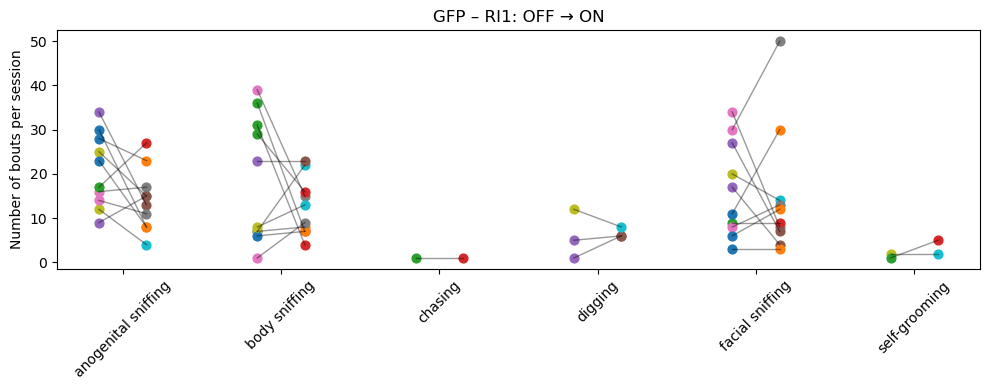

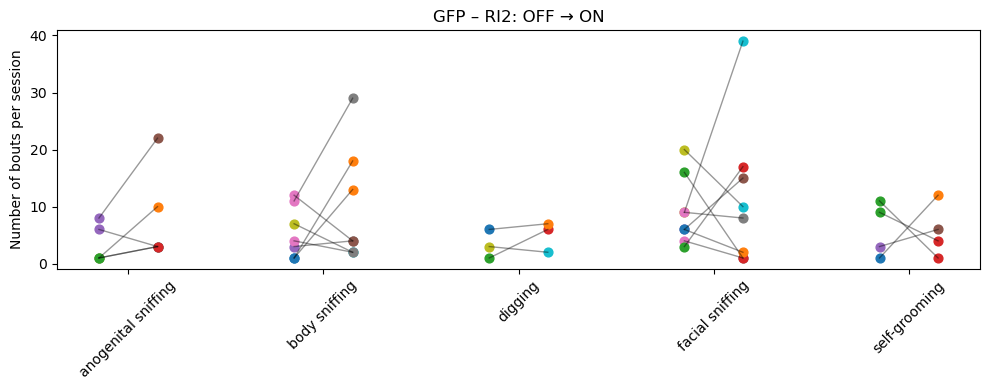

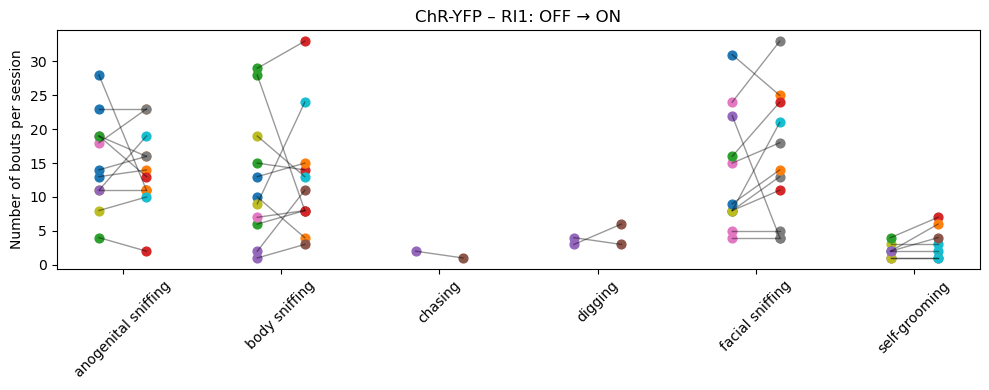

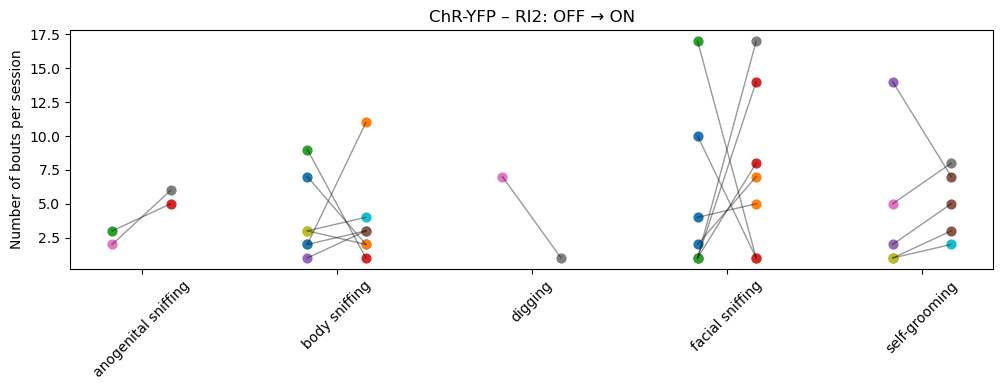

In [17]:
for group in groups:
    for condition in ["RI1","RI2"]:

        plt.figure(figsize=(10,4))

        gdf = bout_counts_paired[
            (bout_counts_paired["Group"] == group) &
            (bout_counts_paired["Condition"] == condition)
        ]

        behaviors = sorted(gdf["Behavior"].unique())
        x_pos = {b: i for i, b in enumerate(behaviors)}

        for (subj, beh), sdf in gdf.groupby(["SubjectID", "Behavior"]):

            wide = (
                sdf
                .groupby(["SubjectID","Laser"])["BoutCount"]
                .sum()
                .unstack()
            )

            if not {"OFF","ON"}.issubset(wide.columns):
                continue

            x = x_pos[beh]

            plt.plot(
                [x - 0.15, x + 0.15],
                [wide.loc[subj, "OFF"], wide.loc[subj, "ON"]],
                color="black",
                alpha=0.4,
                linewidth=1
            )

            plt.scatter(x - 0.15, wide.loc[subj, "OFF"], s=40)
            plt.scatter(x + 0.15, wide.loc[subj, "ON"], s=40)

        plt.xticks(range(len(behaviors)), behaviors, rotation=45)
        plt.ylabel("Number of bouts per session")
        plt.title(f"{group} – {condition}: OFF → ON")
        plt.tight_layout()
        plt.show()

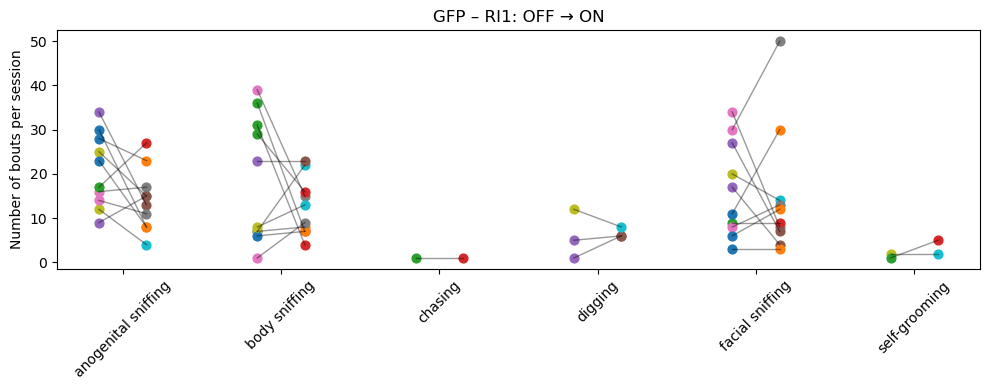

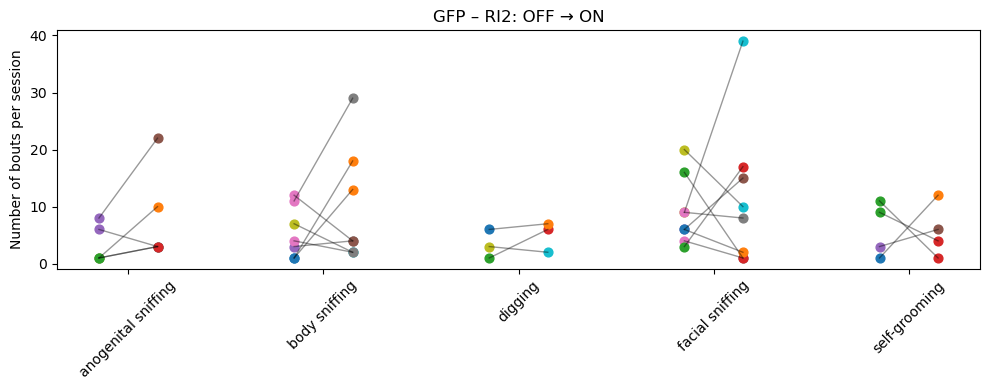

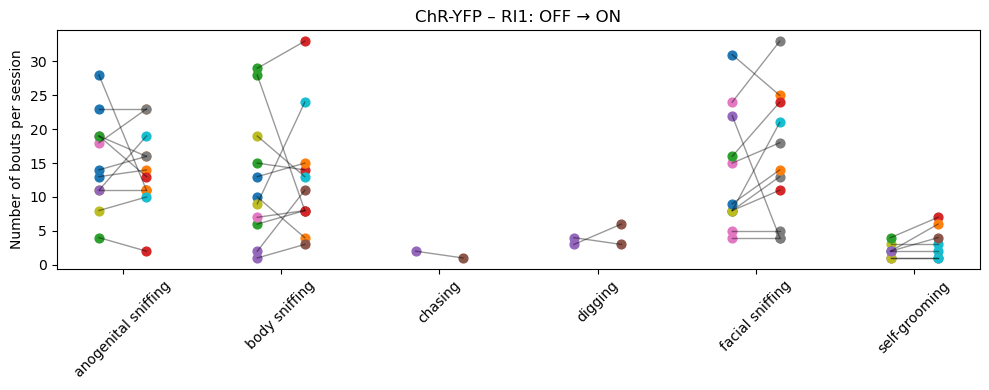

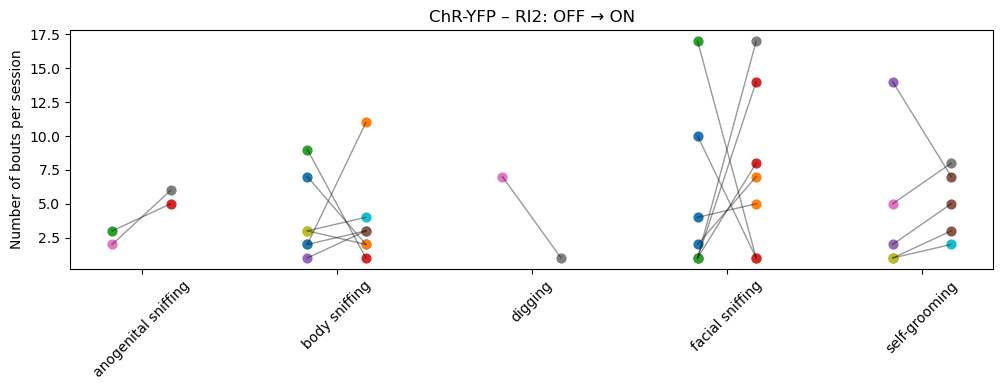

In [16]:
for group in groups:
    for condition in ["RI1","RI2"]:

        plt.figure(figsize=(10,4))

        gdf = bout_counts_paired[
            (bout_counts_paired["Group"] == group) &
            (bout_counts_paired["Condition"] == condition)
        ]

        behaviors = sorted(gdf["Behavior"].unique())
        x_pos = {b: i for i, b in enumerate(behaviors)}

        for (subj, beh), sdf in gdf.groupby(["SubjectID", "Behavior"]):

            wide = (
                sdf
                .groupby(["SubjectID","Laser"])["BoutCount"]
                .sum()
                .unstack()
            )

            if not {"OFF","ON"}.issubset(wide.columns):
                continue

            x = x_pos[beh]

            plt.plot(
                [x - 0.15, x + 0.15],
                [wide.loc[subj, "OFF"], wide.loc[subj, "ON"]],
                color="black",
                alpha=0.4,
                linewidth=1
            )

            plt.scatter(x - 0.15, wide.loc[subj, "OFF"], s=40)
            plt.scatter(x + 0.15, wide.loc[subj, "ON"], s=40)

        plt.xticks(range(len(behaviors)), behaviors, rotation=45)
        plt.ylabel("Number of bouts per session")
        plt.title(f"{group} – {condition}: OFF → ON")
        plt.tight_layout()
        plt.show()

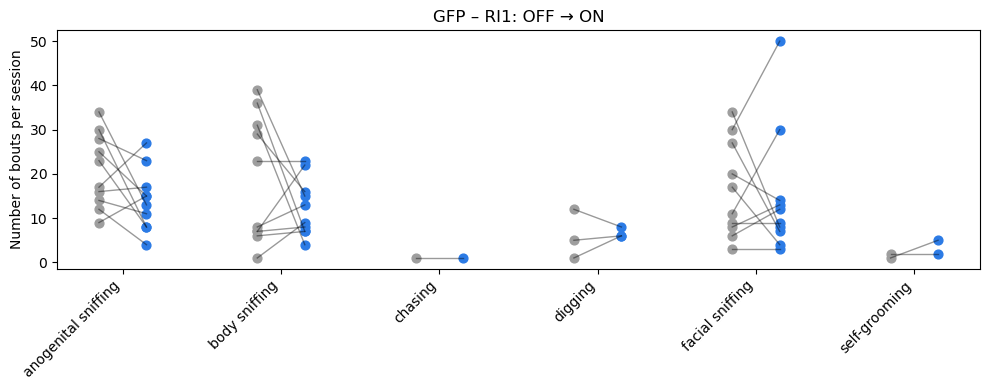

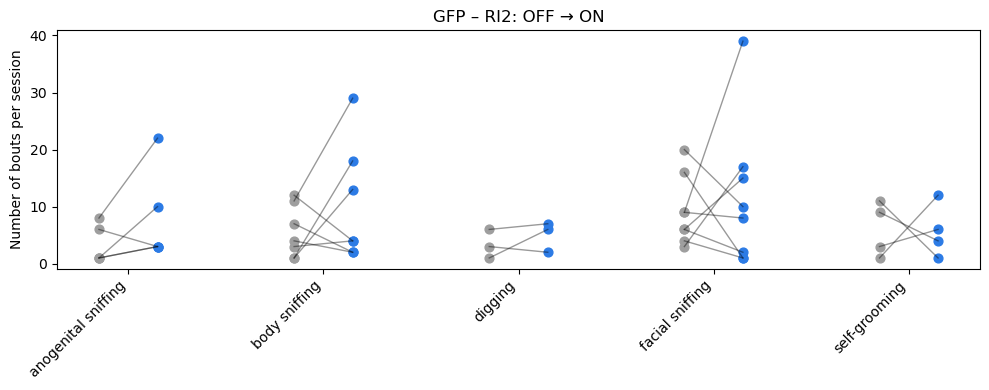

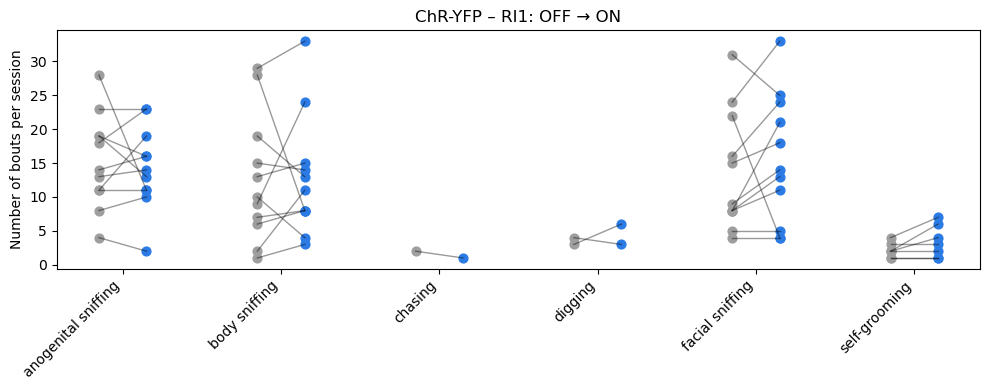

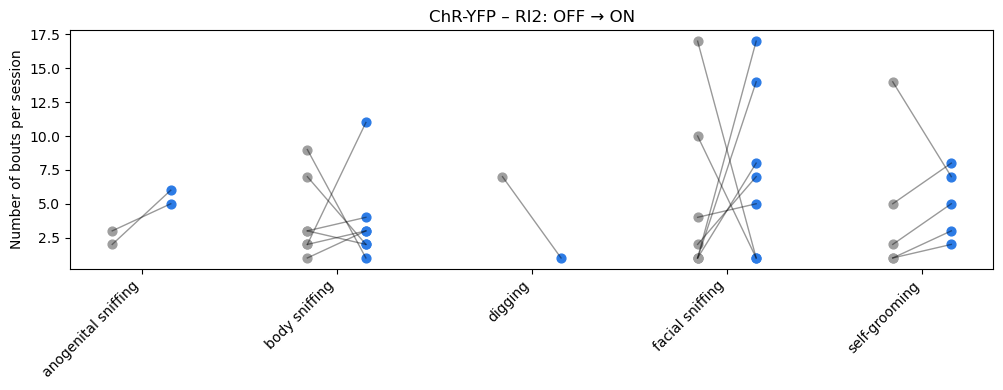

In [15]:
groups = ["GFP", "ChR-YFP"]
conditions = ["RI1", "RI2"]
colors = {"OFF": "#9E9E9E", "ON": "#2C7BE5"}

for group in groups:
    for condition in conditions:

        plt.figure(figsize=(10,4))

        gdf = bout_counts_paired[
            (bout_counts_paired["Group"] == group) &
            (bout_counts_paired["Condition"] == condition)
        ]

        behaviors = sorted(gdf["Behavior"].unique())
        x_pos = {b: i for i, b in enumerate(behaviors)}

        for (subj, beh), sdf in gdf.groupby(["SubjectID", "Behavior"]):

            # SAFE reshape (handles duplicates gracefully)
            wide = (
                sdf
                .groupby(["SubjectID", "Laser"])["BoutCount"]
                .sum()
                .unstack()
            )

            if not {"OFF", "ON"}.issubset(wide.columns):
                continue

            x = x_pos[beh]

            plt.plot(
                [x - 0.15, x + 0.15],
                [wide.loc[subj, "OFF"], wide.loc[subj, "ON"]],
                color="black",
                alpha=0.4,
                linewidth=1
            )

            plt.scatter(x - 0.15, wide.loc[subj, "OFF"], color=colors["OFF"], s=40)
            plt.scatter(x + 0.15, wide.loc[subj, "ON"],  color=colors["ON"],  s=40)

        plt.xticks(range(len(behaviors)), behaviors, rotation=45, ha="right")
        plt.ylabel("Number of bouts per session")
        plt.title(f"{group} – {condition}: OFF → ON")
        plt.tight_layout()
        plt.show()


In [18]:
print(bout_counts_paired.columns)


Index(['SubjectID', 'Group', 'Laser', 'Behavior', 'Condition', 'BoutCount'], dtype='object')


In [19]:
def infer_sex(subject_id):
    cage = int(subject_id.split("_")[0])
    if cage <= 4:
        return "Female"
    else:
        return "Male"

bout_counts_paired["Sex"] = bout_counts_paired["SubjectID"].apply(infer_sex)


In [20]:
print(bout_counts_paired["Sex"].value_counts())


Sex
Male      148
Female    108
Name: count, dtype: int64


In [40]:
import matplotlib.pyplot as plt

groups = ["GFP", "ChR-YFP"]
sexes = ["Female", "Male"]

colors = {"OFF": "#9E9E9E", "ON": "#2C7BE5"}

for sex in sexes:
    for group in groups:

        plt.figure(figsize=(10,4))

        gdf = bout_counts_paired[
            (bout_counts_paired["Group"] == group) &
            (bout_counts_paired["Sex"] == sex)
        ]

        behaviors = sorted(gdf["Behavior"].unique())
        x_pos = {b: i for i, b in enumerate(behaviors)}

        for (subj, beh), sdf in gdf.groupby(["SubjectID", "Behavior"]):

            wide = sdf.pivot(index="SubjectID", columns="Laser", values="BoutCount")

            if not {"OFF", "ON"}.issubset(wide.columns):
                continue

            x = x_pos[beh]

            plt.plot(
                [x - 0.15, x + 0.15],
                [wide.loc[subj, "OFF"], wide.loc[subj, "ON"]],
                color="black",
                alpha=0.4,
                linewidth=1
            )

            plt.scatter(x - 0.15, wide.loc[subj, "OFF"], color=colors["OFF"], s=40)
            plt.scatter(x + 0.15, wide.loc[subj, "ON"],  color=colors["ON"],  s=40)

        plt.xticks(range(len(behaviors)), behaviors, rotation=45, ha="right")
        plt.ylabel("Number of bouts per session")
        plt.title(f"{sex} | {group}: Paired bout counts")
        plt.tight_layout()
        plt.show()



ValueError: Index contains duplicate entries, cannot reshape

<Figure size 1000x400 with 0 Axes>

defining social investiagtion

In [41]:
investigation_behaviors = [
    "facial sniffing",
    "body sniffing",
    "anogenital sniffing"
]

invest_df = boris_df[
    boris_df["Behavior"].isin(investigation_behaviors)
].copy()

In [23]:
invest_time = (
    invest_df
    .groupby(["SubjectID", "Group", "Condition", "Laser"], as_index=False)
    .agg(InvestigationTime=("Duration", "sum"))
)

In [24]:
paired = (
    invest_time
    .groupby(["SubjectID", "Group", "Condition"])["Laser"]
    .nunique()
    .reset_index()
)

paired = paired[paired["Laser"] == 2]

invest_time_paired = invest_time.merge(
    paired[["SubjectID", "Group", "Condition"]],
    on=["SubjectID", "Group", "Condition"],
    how="inner"
)

In [25]:
print(invest_time_paired.groupby(["Condition", "Group", "Laser"]).size())

Condition  Group    Laser
RI1        ChR-YFP  OFF      11
                    ON       11
           GFP      OFF      10
                    ON       10
RI2        ChR-YFP  OFF      10
                    ON       10
           GFP      OFF       9
                    ON        9
dtype: int64


checking to make sure files for subjects are here can check with subj ID

In [26]:
file_presence = (
    boris_df
    .groupby(["SubjectID", "Group", "Laser"])["File"]
    .nunique()
    .reset_index(name="N_files")
)

file_presence[file_presence["SubjectID"].isin(["2_2", "8_2"])]


,SubjectID,Group,Laser,N_files
6,2_2,GFP,OFF,2
7,2_2,GFP,ON,2
38,8_2,GFP,OFF,2
39,8_2,GFP,ON,2


Checking to make sure I calculated social investiagation time per subj using subj ID 

In [27]:
investigation_behaviors = [
    "facial sniffing",
    "body sniffing",
    "anogenital sniffing"
]

invest_presence = (
    boris_df[
        boris_df["Behavior"].isin(investigation_behaviors)
    ]
    .groupby(["SubjectID", "Group", "Laser"])["Duration"]
    .sum()
    .reset_index(name="TotalInvestigationTime")
)

invest_presence[invest_presence["SubjectID"].isin(["2_2", "8_2"])]


,SubjectID,Group,Laser,TotalInvestigationTime
6,2_2,GFP,OFF,75.558
7,2_2,GFP,ON,68.124
38,8_2,GFP,OFF,67.269
39,8_2,GFP,ON,41.240


In [28]:
diagnostic = (
    file_presence
    .merge(
        invest_presence,
        on=["SubjectID", "Group", "Laser"],
        how="left"
    )
    .fillna({"TotalInvestigationTime": 0})
)

diagnostic[diagnostic["SubjectID"].isin(["5_1", "3_3"])]


,SubjectID,Group,Laser,N_files,TotalInvestigationTime
20,5_1,ChR-YFP,OFF,2,75.820
21,5_1,ChR-YFP,ON,2,123.693


In [29]:
file_table = (
    boris_df
    .groupby(["SubjectID", "Group", "Laser"])["File"]
    .nunique()
    .reset_index(name="N_files")
)

file_table.sort_values(["Group", "SubjectID", "Laser"])


,SubjectID,Group,Laser,N_files
0,1_1,ChR-YFP,OFF,2
1,1_1,ChR-YFP,ON,2
2,1_2,ChR-YFP,OFF,2
3,1_2,ChR-YFP,ON,2
10,3_1,ChR-YFP,OFF,2
11,3_1,ChR-YFP,ON,2
12,3_2,ChR-YFP,OFF,2
13,3_2,ChR-YFP,ON,2
20,5_1,ChR-YFP,OFF,2
21,5_1,ChR-YFP,ON,2


checking to see pre and post mice 4.1 only pre mouse died 

In [30]:
# All OFF sessions (regardless of behavior)
all_off_files = (
    boris_df[boris_df["Laser"] == "OFF"]
    .groupby(["SubjectID", "Group"])["File"]
    .nunique()
    .reset_index(name="N_OFF_files")
)

# OFF sessions WITH investigation
off_invest = (
    boris_df[
        (boris_df["Laser"] == "OFF") &
        (boris_df["Behavior"].isin([
            "facial sniffing",
            "body sniffing",
            "anogenital sniffing"
        ]))
    ]
    .groupby(["SubjectID", "Group"])["File"]
    .nunique()
    .reset_index(name="N_OFF_invest_files")
)

check = (
    all_off_files
    .merge(off_invest, on=["SubjectID", "Group"], how="left")
    .fillna({"N_OFF_invest_files": 0})
)

check[check["Group"] == "GFP"]


,SubjectID,Group,N_OFF_files,N_OFF_invest_files
2,2_1,GFP,2,2
3,2_2,GFP,2,2
4,2_3,GFP,2,2
7,4_1,GFP,1,1
8,4_2,GFP,2,2
9,4_3,GFP,2,2
13,6_2,GFP,2,2
14,6_3,GFP,2,2
18,8_1,GFP,2,2
19,8_2,GFP,2,2


In [31]:
exclude_subjects = ["1_3", "3_3"]  # both have bad histology 

invest_time_paired = invest_time[
    ~invest_time["SubjectID"].isin(exclude_subjects)
].copy()


In [32]:
paired = (
    invest_time
    .groupby(["SubjectID", "Group", "Condition"])["Laser"]
    .nunique()
    .reset_index()
)

paired = paired[paired["Laser"] == 2]

invest_time_paired = invest_time.merge(
    paired[["SubjectID", "Group", "Condition"]],
    on=["SubjectID", "Group", "Condition"],
    how="inner"
)


In [33]:
print(invest_time.columns)

Index(['SubjectID', 'Group', 'Condition', 'Laser', 'InvestigationTime'], dtype='object')


In [34]:
invest_plot = invest_time_paired.copy()


In [35]:
invest_plot.columns


Index(['SubjectID', 'Group', 'Condition', 'Laser', 'InvestigationTime'], dtype='object')

In [36]:
invest_plot

,SubjectID,Group,Condition,Laser,InvestigationTime
0,1_1,ChR-YFP,RI1,OFF,68.601
1,1_1,ChR-YFP,RI1,ON,61.296
2,1_1,ChR-YFP,RI2,OFF,0.625
3,1_1,ChR-YFP,RI2,ON,8.810
4,1_2,ChR-YFP,RI1,OFF,40.841
...,...,...,...,...,...
75,8_3,GFP,RI2,ON,6.125
76,9_1,ChR-YFP,RI1,OFF,49.251
77,9_1,ChR-YFP,RI1,ON,45.265
78,9_1,ChR-YFP,RI2,OFF,0.250


pre-MOE behavior 

C:\Users\sjs93\AppData\Local\Temp\ipykernel_56508\470333434.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


KeyError: 'SubjSex'

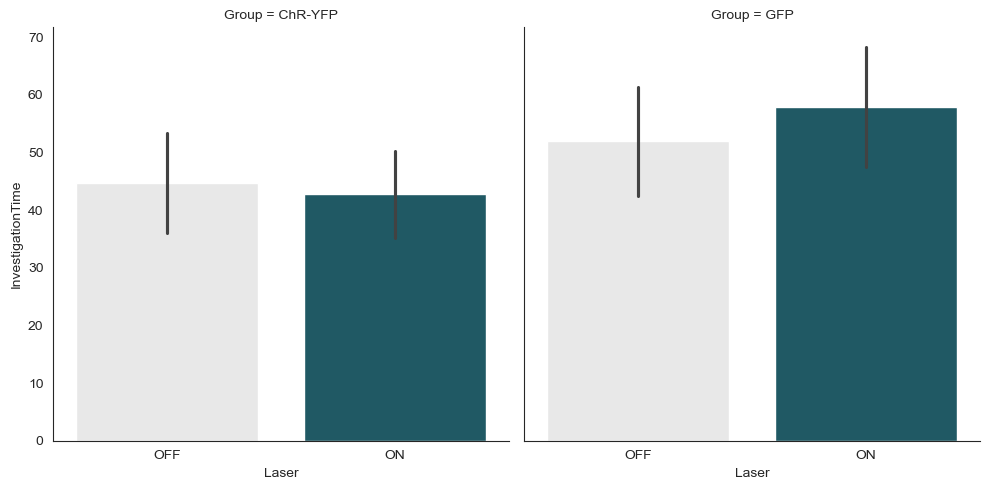

In [42]:
sns.set_style("white")

laser_order = ["OFF", "ON"]

palette_laser = {
    "OFF": "#E8E8E8",   # gray
    "ON":  "#15616F"    # deeper blue (more serious than pastel)
}

sex_markers = {
    "Female": "o",
    "Male": "^"
}

g = sns.catplot(
    data=invest_plot,
    x="Laser",
    y="InvestigationTime",
    col="Group",
    kind="bar",
    order=laser_order,
    palette=palette_laser,
    errorbar="se",
    height=5,
    aspect=1.0,
    sharey=True
)

# ----------------------------
# Overlay paired lines + sex markers
# ----------------------------

for ax, (group, df_group) in zip(g.axes.flat, invest_plot.groupby("Group")):
    
    for subject, df_sub in df_group.groupby("SubjectID"):
        
        if set(df_sub["Laser"]) == set(laser_order):
            
            df_sub = df_sub.set_index("Laser").loc[laser_order]
            sex = df_sub["SubjSex"].iloc[0]
            
            x = np.arange(len(laser_order))
            
            # paired line
            ax.plot(
                x,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1.5,
                zorder=3
            )
            
            # points with sex marker
            ax.scatter(
                x,
                df_sub["InvestigationTime"],
                marker=sex_markers[sex],
                color="black",
                s=70,
                zorder=4
            )

    # Axis formatting
    ax.set_xticks(np.arange(len(laser_order)))
    ax.set_xticklabels(laser_order, fontsize=18, fontweight="bold")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    ax.tick_params(width=2, labelsize=16)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles("{col_name}", size=22)

plt.tight_layout()
plt.show()

In [43]:
invest_plot["SubjSex"] = (
    invest_plot["SubjectID"]
    .str.split("_")
    .str[0]
    .astype(int)
    .apply(lambda x: "Female" if x <= 4 else "Male")
)

In [44]:
print(invest_plot[["SubjectID","SubjSex"]].drop_duplicates().sort_values("SubjectID"))

   SubjectID SubjSex
0        1_1  Female
4        1_2  Female
8        2_1  Female
12       2_2  Female
16       2_3  Female
20       3_1  Female
24       3_2  Female
28       4_1  Female
30       4_2  Female
34       4_3  Female
38       5_1    Male
42       5_2    Male
44       5_3    Male
48       6_2    Male
50       6_3    Male
52       7_1    Male
56       7_2    Male
60       7_3    Male
64       8_1    Male
68       8_2    Male
72       8_3    Male
76       9_1    Male


C:\Users\sjs93\AppData\Local\Temp\ipykernel_56508\1292499179.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


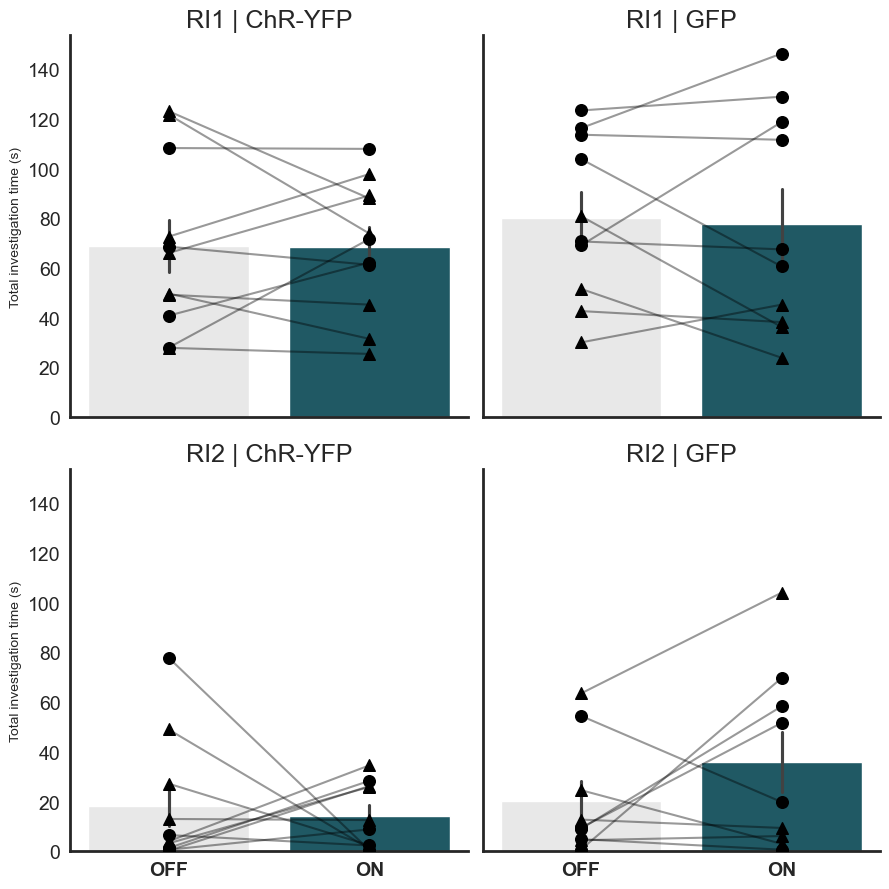

In [45]:
sns.set_style("white")

laser_order = ["OFF", "ON"]

palette_laser = {
    "OFF": "#E8E8E8",
    "ON":  "#15616F"
}

sex_markers = {
    "Female": "o",
    "Male": "^"
}

g = sns.catplot(
    data=invest_plot,
    x="Laser",
    y="InvestigationTime",
    col="Group",
    row="Condition",          # 👈 separates RI1 vs RI2
    kind="bar",
    order=laser_order,
    palette=palette_laser,
    errorbar="se",
    height=4.5,
    aspect=1.0,
    sharey=True
)

# ----------------------------
# Overlay paired lines + sex markers
# ----------------------------

# Loop through each subplot
for (cond, group), ax in zip(
    invest_plot.groupby(["Condition", "Group"]).groups.keys(),
    g.axes.flat
):

    df_panel = invest_plot[
        (invest_plot["Condition"] == cond) &
        (invest_plot["Group"] == group)
    ]

    for subject, df_sub in df_panel.groupby("SubjectID"):

        if set(df_sub["Laser"]) == set(laser_order):

            df_sub = df_sub.set_index("Laser").loc[laser_order]
            sex = df_sub["SubjSex"].iloc[0]

            x = np.arange(len(laser_order))

            # paired line
            ax.plot(
                x,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1.5,
                zorder=3
            )

            # points with sex marker
            ax.scatter(
                x,
                df_sub["InvestigationTime"],
                marker=sex_markers[sex],
                color="black",
                s=70,
                zorder=4
            )

    # Axis formatting
    ax.set_xticks(np.arange(len(laser_order)))
    ax.set_xticklabels(laser_order, fontsize=16, fontweight="bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    ax.tick_params(width=2, labelsize=14)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles(row_template="{row_name}", col_template="{col_name}", size=18)

plt.tight_layout()
plt.show()

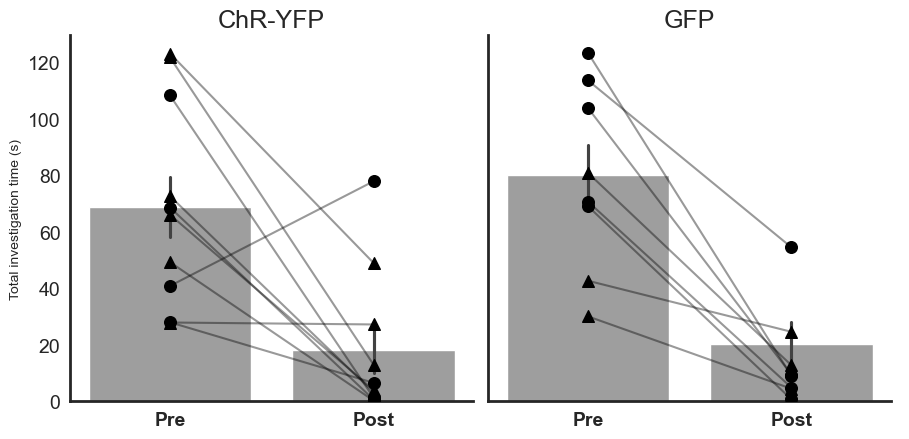

In [47]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")

# ----------------------------
# 1. FILTER: OFF ONLY
# ----------------------------
df_off = invest_plot[invest_plot["Laser"] == "OFF"].copy()

# ----------------------------
# 2. MAP RI1 → Pre, RI2 → Post
# ----------------------------
df_off["Phase"] = df_off["Condition"].map({
    "RI1": "Pre",
    "RI2": "Post"
})

phase_order = ["Pre", "Post"]

# ----------------------------
# 3. PLOT (no more row split)
# ----------------------------
g = sns.catplot(
    data=df_off,
    x="Phase",
    y="InvestigationTime",
    col="Group",          # keep ArchT vs Control
    kind="bar",
    order=phase_order,
    color="#9E9E9E",
    errorbar="se",
    height=4.5,
    aspect=1.0,
    sharey=True
)

# ----------------------------
# 4. OVERLAY PAIRED LINES
# ----------------------------
for group, ax in zip(df_off["Group"].unique(), g.axes.flat):

    df_panel = df_off[df_off["Group"] == group]

    for subject, df_sub in df_panel.groupby("SubjectID"):

        if set(df_sub["Phase"]) == set(phase_order):

            df_sub = df_sub.set_index("Phase").loc[phase_order]
            sex = df_sub["SubjSex"].iloc[0]

            x = np.arange(len(phase_order))

            # paired line
            ax.plot(
                x,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1.5,
                zorder=3
            )

            # points with sex markers
            ax.scatter(
                x,
                df_sub["InvestigationTime"],
                marker=sex_markers[sex],
                color="black",
                s=70,
                zorder=4
            )

    ax.set_xticks(np.arange(len(phase_order)))
    ax.set_xticklabels(phase_order, fontsize=16, fontweight="bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    ax.tick_params(width=2, labelsize=14)

# ----------------------------
# 5. LABELS
# ----------------------------
g.set_axis_labels("", "Total investigation time (s)")
g.set_titles(col_template="{col_name}", size=18)

plt.tight_layout()
plt.show()

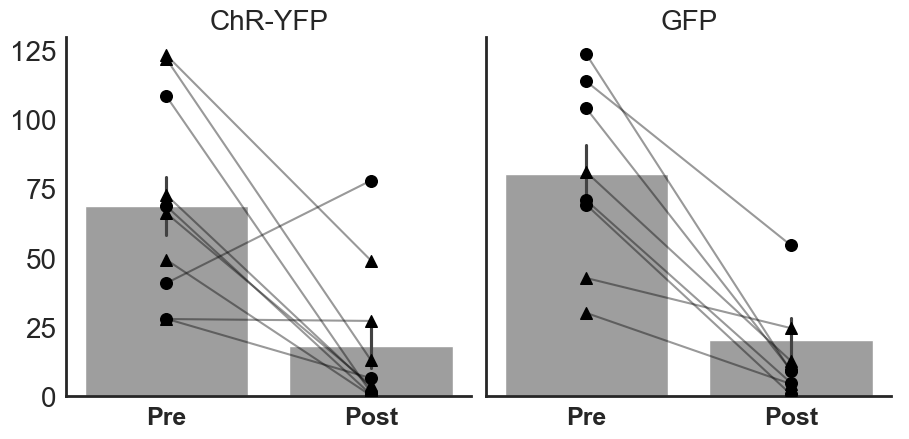

In [49]:
# ----------------------------
# 3. PLOT
# ----------------------------
g = sns.catplot(
    data=df_off,
    x="Phase",
    y="InvestigationTime",
    col="Group",
    kind="bar",
    order=phase_order,
    color="#9E9E9E",
    errorbar="se",
    height=4.5,
    aspect=1.0,
    sharey=True
)

# 🔥 MAKE BACKGROUND TRANSPARENT
g.figure.patch.set_alpha(0)

# ----------------------------
# 4. OVERLAY + FORMAT
# ----------------------------
for group, ax in zip(df_off["Group"].unique(), g.axes.flat):

    ax.set_facecolor("none")  # transparent panel

    df_panel = df_off[df_off["Group"] == group]

    for subject, df_sub in df_panel.groupby("SubjectID"):

        if set(df_sub["Phase"]) == set(phase_order):

            df_sub = df_sub.set_index("Phase").loc[phase_order]
            sex = df_sub["SubjSex"].iloc[0]

            x = np.arange(len(phase_order))

            ax.plot(
                x,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1.5,
                zorder=3
            )

            ax.scatter(
                x,
                df_sub["InvestigationTime"],
                marker=sex_markers[sex],
                color="black",
                s=70,
                zorder=4
            )

    # Axis formatting
    ax.set_xticks(np.arange(len(phase_order)))
    ax.set_xticklabels(phase_order, fontsize=18, fontweight="bold")

    # 🔥 BIGGER Y-AXIS
    ax.tick_params(axis='y', labelsize=20, width=2)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

# ----------------------------
# LABELS
# ----------------------------
g.set_axis_labels("", "")
g.set_titles(col_template="{col_name}", size=20)

plt.tight_layout()
plt.show()

C:\Users\sjs93\AppData\Local\Temp\ipykernel_56508\219629208.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


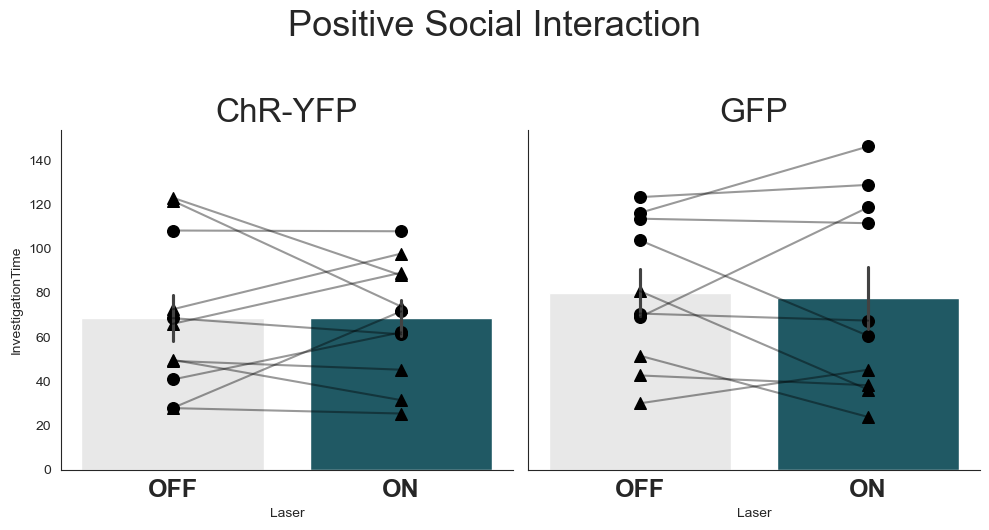

In [46]:
sns.set_style("white")

laser_order = ["OFF", "ON"]

palette_laser = {
    "OFF": "#E8E8E8",
    "ON":  "#15616F"
}

sex_markers = {
    "Female": "o",
    "Male": "^"
}

ri1_df = invest_plot[invest_plot["Condition"] == "RI1"].copy()

g = sns.catplot(
    data=ri1_df,
    x="Laser",
    y="InvestigationTime",
    col="Group",
    kind="bar",
    order=laser_order,
    palette=palette_laser,
    errorbar="se",
    height=5,
    aspect=1.0,
    sharey=True
)

for ax, (group, df_group) in zip(g.axes.flat, ri1_df.groupby("Group")):

    for subject, df_sub in df_group.groupby("SubjectID"):

        if set(df_sub["Laser"]) == set(laser_order):

            df_sub = df_sub.set_index("Laser").loc[laser_order]
            sex = df_sub["SubjSex"].iloc[0]

            x = np.arange(len(laser_order))

            ax.plot(x, df_sub["InvestigationTime"],
                    color="black", alpha=0.4, linewidth=1.5)

            ax.scatter(x, df_sub["InvestigationTime"],
                       marker=sex_markers[sex],
                       color="black", s=70)

    ax.set_xticks(np.arange(len(laser_order)))
    ax.set_xticklabels(laser_order, fontsize=18, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

g.set_titles("{col_name}", size=24)
plt.suptitle("Positive Social Interaction", fontsize=26, y=1.05)

plt.tight_layout()
plt.show()

C:\Users\sjs93\AppData\Local\Temp\ipykernel_36704\1741862563.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


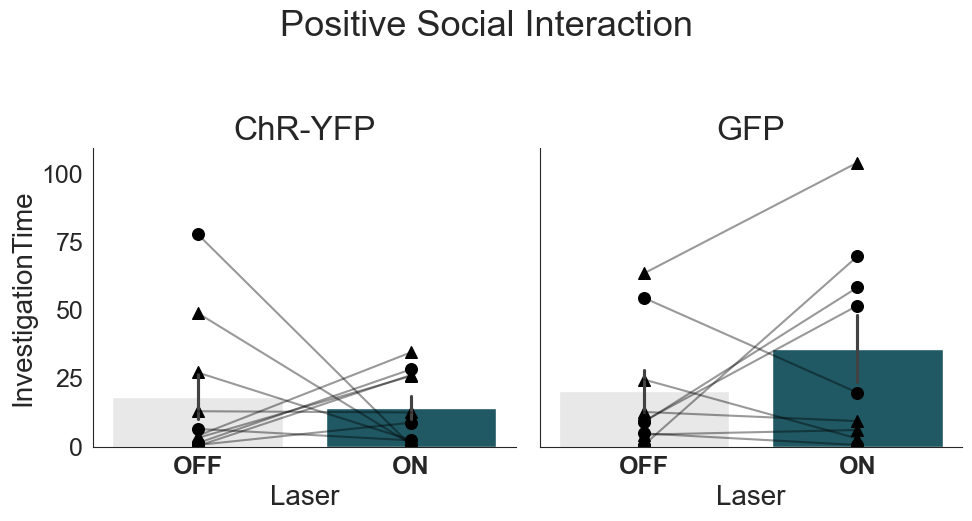

In [220]:
sns.set_style("white")

laser_order = ["OFF", "ON"]

palette_laser = {
    "OFF": "#E8E8E8",
    "ON":  "#15616F"
}

sex_markers = {
    "Female": "o",
    "Male": "^"
}

ri1_df = invest_plot[invest_plot["Condition"] == "RI2"].copy()

g = sns.catplot(
    data=ri1_df,
    x="Laser",
    y="InvestigationTime",
    col="Group",
    kind="bar",
    order=laser_order,
    palette=palette_laser,
    errorbar="se",
    height=5,
    aspect=1.0,
    sharey=True
)

for ax, (group, df_group) in zip(g.axes.flat, ri1_df.groupby("Group")):

    for subject, df_sub in df_group.groupby("SubjectID"):

        if set(df_sub["Laser"]) == set(laser_order):

            df_sub = df_sub.set_index("Laser").loc[laser_order]
            sex = df_sub["SubjSex"].iloc[0]

            x = np.arange(len(laser_order))

            ax.plot(x, df_sub["InvestigationTime"],
                    color="black", alpha=0.4, linewidth=1.5)

            ax.scatter(x, df_sub["InvestigationTime"],
                       marker=sex_markers[sex],
                       color="black", s=70)

    ax.set_xticks(np.arange(len(laser_order)))
    ax.set_xticklabels(laser_order, fontsize=18, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

g.set_titles("{col_name}", size=24)
plt.suptitle("Positive Social Interaction", fontsize=26, y=1.05)

plt.tight_layout()
plt.show()

In [214]:
print(invest_plot.columns)

Index(['SubjectID', 'Group', 'Condition', 'Laser', 'InvestigationTime'], dtype='object')


In [165]:
print("Unique subjects in invest_plot:")
print(sorted(invest_plot["SubjectID"].unique()))
print()

print("Subjects per Group:")
print(invest_plot.groupby("Group")["SubjectID"].unique())
print()

print("Subjects per Group + Laser count:")
print(
    invest_plot
    .groupby(["Group", "SubjectID"])["Laser"]
    .nunique()
)

Unique subjects in invest_plot:
['1_1', '1_2', '2_1', '2_2', '2_3', '3_1', '3_2', '4_1', '4_2', '4_3', '5_1', '5_2', '5_3', '6_2', '6_3', '7_1', '7_2', '7_3', '8_1', '8_2', '8_3', '9_1']

Subjects per Group:
Group
ChR-YFP    [1_1, 1_2, 3_1, 3_2, 5_1, 5_2, 5_3, 7_1, 7_2, ...
GFP        [2_1, 2_2, 2_3, 4_1, 4_2, 4_3, 6_2, 6_3, 8_1, ...
Name: SubjectID, dtype: object

Subjects per Group + Laser count:
Group    SubjectID
ChR-YFP  1_1          2
         1_2          2
         3_1          2
         3_2          2
         5_1          2
         5_2          2
         5_3          2
         7_1          2
         7_2          2
         7_3          2
         9_1          2
GFP      2_1          2
         2_2          2
         2_3          2
         4_1          2
         4_2          2
         4_3          2
         6_2          2
         6_3          2
         8_1          2
         8_2          2
         8_3          2
Name: Laser, dtype: int64


In [166]:
for group in invest_plot["Group"].unique():
    print(f"\n=== GROUP: {group} ===")
    df_group = invest_plot[invest_plot["Group"] == group]
    
    for subject in sorted(df_group["SubjectID"].unique()):
        df_sub = df_group[df_group["SubjectID"] == subject]
        lasers = sorted(df_sub["Laser"].unique())
        print(f"{subject} | Lasers: {lasers}")


=== GROUP: ChR-YFP ===
1_1 | Lasers: ['OFF', 'ON']
1_2 | Lasers: ['OFF', 'ON']
3_1 | Lasers: ['OFF', 'ON']
3_2 | Lasers: ['OFF', 'ON']
5_1 | Lasers: ['OFF', 'ON']
5_2 | Lasers: ['OFF', 'ON']
5_3 | Lasers: ['OFF', 'ON']
7_1 | Lasers: ['OFF', 'ON']
7_2 | Lasers: ['OFF', 'ON']
7_3 | Lasers: ['OFF', 'ON']
9_1 | Lasers: ['OFF', 'ON']

=== GROUP: GFP ===
2_1 | Lasers: ['OFF', 'ON']
2_2 | Lasers: ['OFF', 'ON']
2_3 | Lasers: ['OFF', 'ON']
4_1 | Lasers: ['OFF', 'ON']
4_2 | Lasers: ['OFF', 'ON']
4_3 | Lasers: ['OFF', 'ON']
6_2 | Lasers: ['OFF', 'ON']
6_3 | Lasers: ['OFF', 'ON']
8_1 | Lasers: ['OFF', 'ON']
8_2 | Lasers: ['OFF', 'ON']
8_3 | Lasers: ['OFF', 'ON']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("white")

laser_order = ["OFF", "ON"]

palette_laser = {
    "OFF": "#9E9E9E",   # gray
    "ON":  "#1F4E79"    # deeper blue (more serious than pastel)
}

sex_markers = {
    "Female": "o",
    "Male": "^"
}

g = sns.catplot(
    data=invest_plot,
    x="Laser",
    y="InvestigationTime",
    col="Group",
    kind="bar",
    order=laser_order,
    palette=palette_laser,
    errorbar="se",
    height=5,
    aspect=1.0,
    sharey=True
)

# ----------------------------
# Overlay paired lines + sex markers
# ----------------------------

for ax, (group, df_group) in zip(g.axes.flat, invest_plot.groupby("Group")):
    
    for subject, df_sub in df_group.groupby("SubjectID"):
        
        if set(df_sub["Laser"]) == set(laser_order):
            
            df_sub = df_sub.set_index("Laser").loc[laser_order]
            sex = df_sub["SubjSex"].iloc[0]
            
            x = np.arange(len(laser_order))
            
            # paired line
            ax.plot(
                x,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1.5,
                zorder=3
            )
            
            # points with sex marker
            ax.scatter(
                x,
                df_sub["InvestigationTime"],
                marker=sex_markers[sex],
                color="black",
                s=70,
                zorder=4
            )

    # Axis formatting
    ax.set_xticks(np.arange(len(laser_order)))
    ax.set_xticklabels(laser_order, fontsize=18, fontweight="bold")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    ax.tick_params(width=2, labelsize=16)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles("{col_name}", size=22)

plt.tight_layout()
plt.show()

In [100]:
invest_plot_clean = invest_plot.copy()

invest_plot_clean = invest_plot_clean[
    ~invest_plot_clean["SubjectID"].isin(exclude_subjects)
]

# enforce pairing AFTER exclusion
paired = (
    invest_plot_clean
    .groupby(["SubjectID", "Group"])["Laser"]
    .nunique()
    .reset_index()
    .query("Laser == 2")
)

invest_plot_clean = invest_plot_clean.merge(
    paired[["SubjectID","Group"]],
    on=["SubjectID","Group"],
    how="inner"
)

C:\Users\sjs93\AppData\Local\Temp\ipykernel_36704\3371639298.py:33: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


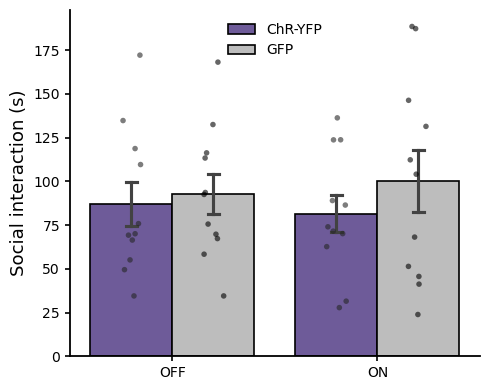

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Orders ---
laser_order = ["OFF", "ON"]
group_order = ["ChR-YFP", "GFP"]

# --- Colors ---
group_palette = {
    "ChR-YFP": "#6A51A3",  # purple
    "GFP": "#BDBDBD"       # gray
}

plt.figure(figsize=(5, 4))

# --- Bar plot (mean ± SEM) ---
sns.barplot(
    data=invest_plot,
    x="Laser",
    y="InvestigationTime",
    hue="Group",
    order=laser_order,
    hue_order=group_order,
    errorbar="se",
    palette=group_palette,
    edgecolor="black",
    linewidth=1.2,
    capsize=0.1
)

# --- Overlay jittered individual points ---
sns.stripplot(
    data=invest_plot,
    x="Laser",
    y="InvestigationTime",
    hue="Group",
    order=laser_order,
    hue_order=group_order,
    dodge=True,
    color="black",
    size=4,
    alpha=0.6
)

# --- Clean up double legend (stripplot adds another) ---
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], frameon=False)

# --- Style like paper ---
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.3)
ax.spines["bottom"].set_linewidth(1.3)

ax.set_ylabel("Social interaction (s)", fontsize=13)
ax.set_xlabel("")
ax.tick_params(width=1.2)

plt.tight_layout()
plt.show()


In [102]:
print(invest_plot["Group"].unique())
print(invest_plot["Laser"].unique())
print(invest_plot.head())


['ChR-YFP' 'GFP']
['OFF' 'ON']
  SubjectID    Group Laser  InvestigationTime
0       1_1  ChR-YFP   OFF             69.226
1       1_1  ChR-YFP    ON             70.106
2       1_2  ChR-YFP   OFF            118.716
3       1_2  ChR-YFP    ON             62.666
4       2_1      GFP   OFF            113.309


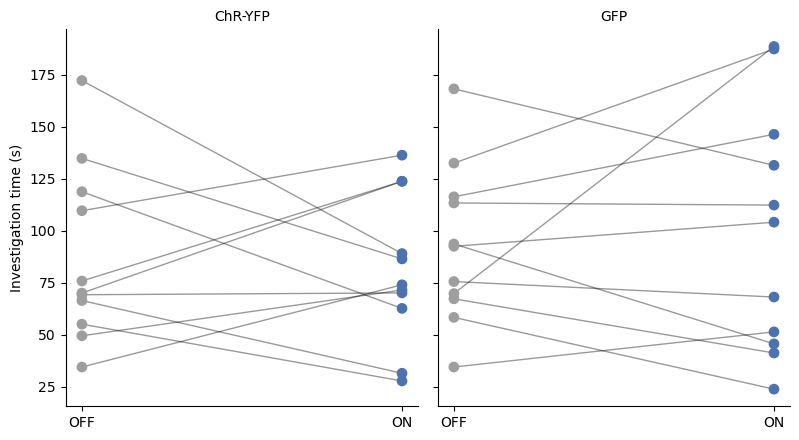

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.FacetGrid(
    invest_plot,
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def paired_lines(data, **kwargs):
    ax = plt.gca()
    for subject, df_sub in data.groupby("SubjectID"):
        if set(df_sub["Laser"]) == {"ON", "OFF"}:
            df_sub = df_sub.sort_values("Laser")  # OFF -> ON
            ax.plot(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1
            )
            ax.scatter(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                c=[palette_laser[l] for l in df_sub["Laser"]],
                s=45,
                zorder=3
            )

g.map_dataframe(paired_lines)

g.set_axis_labels("", "Investigation time (s)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()


In [104]:
(
    boris_df
    .assign(
        Behavior=lambda df: df["Behavior"].astype(str).str.strip().str.lower()
    )
    .pivot_table(
        index=["Behavior", "Group"],
        columns="Laser",
        values="File",     # any column works, we just count rows
        aggfunc="count",
        fill_value=0
    )
    .sort_values(["Group"], ascending=True)
)


,Laser,OFF,ON
Behavior,Group,,
anogenital sniffing,ChR-YFP,179,181
body sniffing,ChR-YFP,171,188
chasing,ChR-YFP,8,6
digging,ChR-YFP,46,22
facial sniffing,ChR-YFP,211,236
self-grooming,ChR-YFP,57,57
anogenital sniffing,GFP,238,185
body sniffing,GFP,236,208
chasing,GFP,9,23


C:\Users\sjs93\AppData\Local\Temp\ipykernel_36704\1987565655.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
C:\Users\sjs93\AppData\Local\Temp\ipykernel_36704\1987565655.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


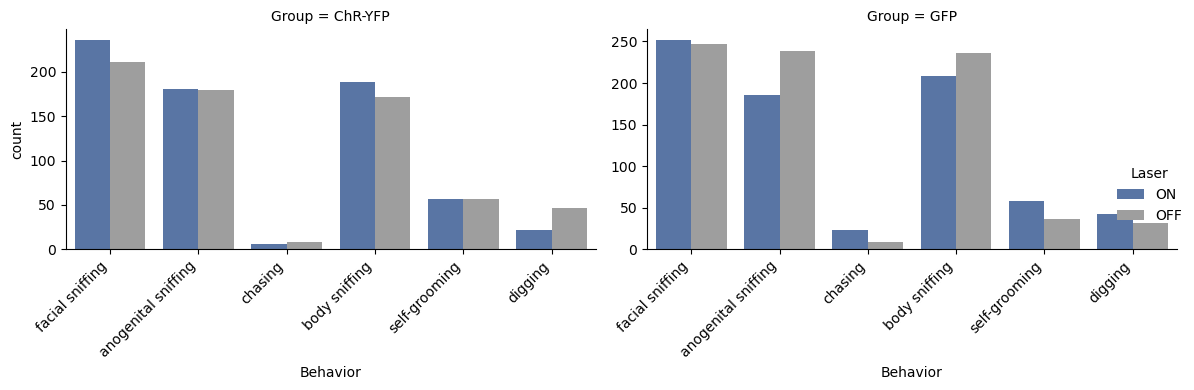

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.catplot(
    data=boris_df.assign(
        Behavior=lambda df: df["Behavior"].astype(str).str.strip().str.lower()
    ),
    x="Behavior",
    hue="Laser",
    col="Group",
    kind="count",
    palette=palette_laser,
    height=4,
    aspect=1.4,
    sharey=False
)

# 🔄 Rotate x-axis labels to 45°
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()



In [106]:

(
    boris_df
    .assign(
        Behavior=lambda df: df["Behavior"].astype(str).str.strip().str.lower()
    )
    .groupby(["Group", "Laser", "Behavior"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Group", "Laser", "Count"], ascending=[True, True, False])
)



,Group,Laser,Behavior,Count
4,ChR-YFP,OFF,facial sniffing,211
0,ChR-YFP,OFF,anogenital sniffing,179
1,ChR-YFP,OFF,body sniffing,171
5,ChR-YFP,OFF,self-grooming,57
3,ChR-YFP,OFF,digging,46
2,ChR-YFP,OFF,chasing,8
10,ChR-YFP,ON,facial sniffing,236
7,ChR-YFP,ON,body sniffing,188
6,ChR-YFP,ON,anogenital sniffing,181
11,ChR-YFP,ON,self-grooming,57


In [107]:
(
    boris_df["Behavior"]
    .astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
)


Behavior
facial sniffing        946
body sniffing          803
anogenital sniffing    783
self-grooming          208
digging                141
chasing                 46
Name: count, dtype: int64

In [108]:
exclude_behaviors = ["self-grooming", "digging"]

investigation_behaviors = (
    boris_df["Behavior"]
    .astype(str)
    .str.lower()
    .str.strip()
    .unique()
)

investigation_behaviors = [
    b for b in investigation_behaviors
    if b not in exclude_behaviors
]

investigation_behaviors


['facial sniffing', 'anogenital sniffing', 'chasing', 'body sniffing']

In [109]:
invest_time = (
    boris_df
    .assign(Behavior=lambda df: df["Behavior"].str.lower().str.strip())
    .query("Behavior in @investigation_behaviors")
    .groupby(["SubjectID", "Group", "Laser"], as_index=False)
    .agg(InvestigationTime=("Duration", "sum"))
)


In [110]:
paired_subjects = (
    invest_time
    .groupby(["SubjectID", "Group"])["Laser"]
    .nunique()
    .reset_index()
    .query("Laser == 2")
)

invest_plot = invest_time.merge(
    paired_subjects[["SubjectID", "Group"]],
    on=["SubjectID", "Group"],
    how="inner"
)


In [111]:
invest_plot.groupby(["Group", "Laser"]).size()


Group    Laser
ChR-YFP  OFF      11
         ON       11
GFP      OFF      11
         ON       11
dtype: int64

In [112]:
invest_plot.columns.tolist()


['SubjectID', 'Group', 'Laser', 'InvestigationTime']

In [113]:
def subject_to_sex(subject_id):
    cage = int(subject_id.split("_")[0])
    return "Female" if cage <= 4 else "Male"

invest_plot = invest_plot.copy()
invest_plot["SubjSex"] = invest_plot["SubjectID"].apply(subject_to_sex)


In [114]:
invest_plot[["SubjectID", "SubjSex"]].drop_duplicates().sort_values("SubjectID")


,SubjectID,SubjSex
0,1_1,Female
2,1_2,Female
4,2_1,Female
6,2_2,Female
8,2_3,Female
10,3_1,Female
12,3_2,Female
14,4_1,Female
16,4_2,Female
18,4_3,Female


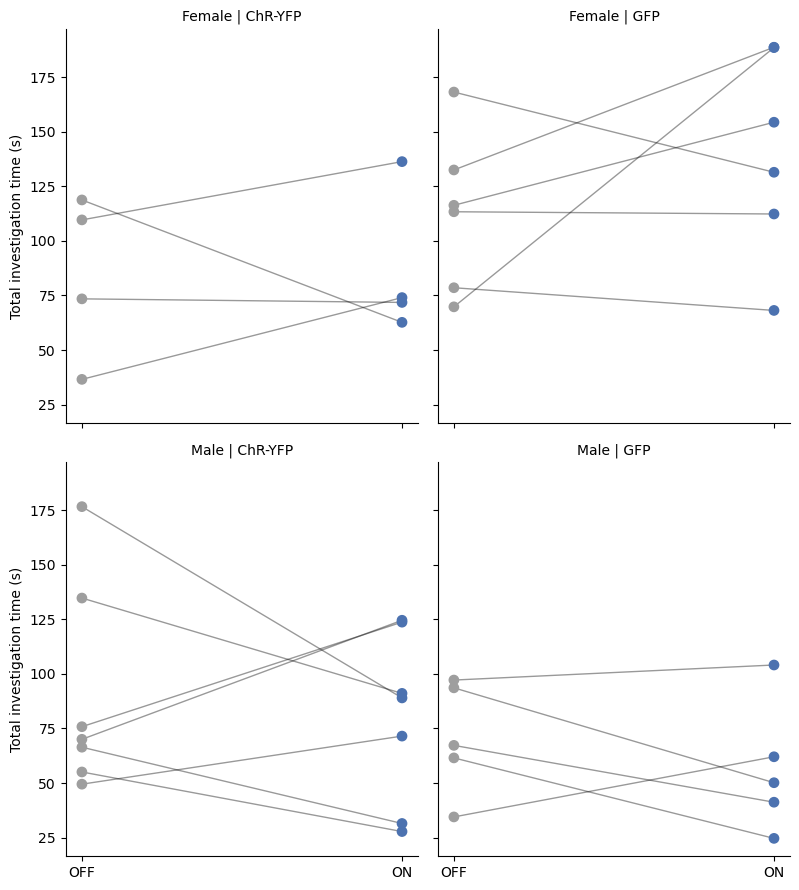

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def paired_lines(data, **kwargs):
    ax = plt.gca()
    for subject, df_sub in data.groupby("SubjectID"):
        if set(df_sub["Laser"]) == {"OFF", "ON"}:
            df_sub = df_sub.sort_values("Laser")
            ax.plot(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1
            )
            ax.scatter(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                c=[palette_laser[l] for l in df_sub["Laser"]],
                s=45,
                zorder=3
            )

g.map_dataframe(paired_lines)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles("{row_name} | {col_name}")
plt.tight_layout()
plt.show()


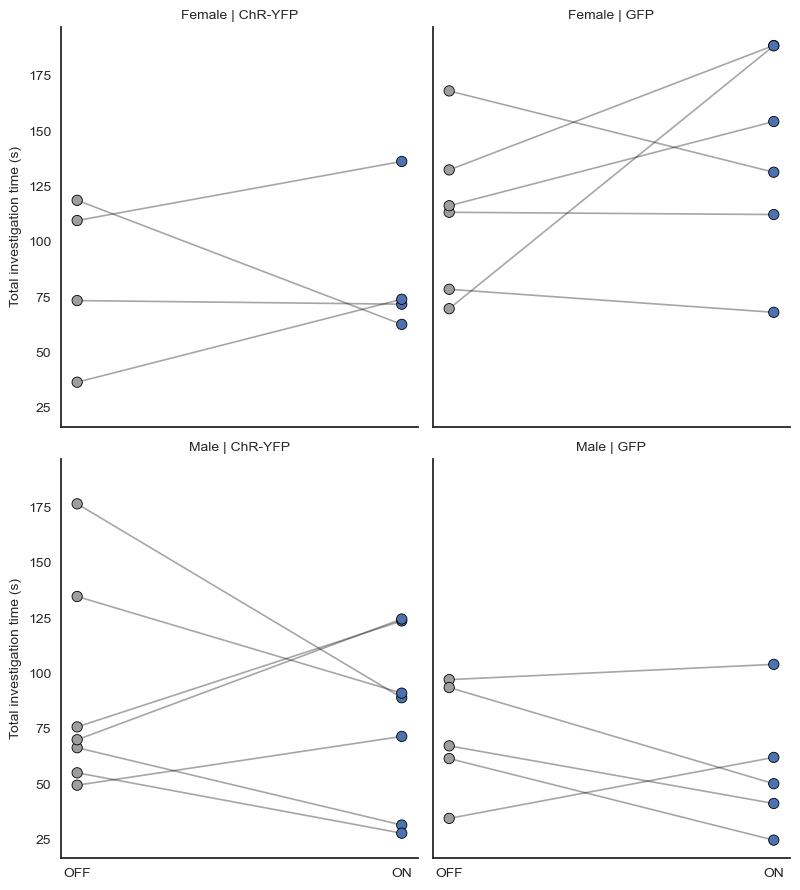

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("white")

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

laser_order = ["OFF", "ON"]

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def paired_lines(data, **kwargs):
    ax = plt.gca()

    for subject, df_sub in data.groupby("SubjectID"):

        if set(df_sub["Laser"]) == set(laser_order):

            df_sub = df_sub.set_index("Laser").loc[laser_order]

            # numeric x positions for consistent alignment
            x_positions = [0, 1]

            ax.plot(
                x_positions,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.35,
                linewidth=1.2,
                zorder=2
            )

            ax.scatter(
                x_positions,
                df_sub["InvestigationTime"],
                c=[palette_laser[l] for l in laser_order],
                s=55,
                edgecolor="black",
                linewidth=0.6,
                zorder=3
            )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(laser_order)

    # Clean axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)
    ax.tick_params(width=1.2)

g.map_dataframe(paired_lines)

g.set_axis_labels("", "Total investigation time (s)")

# Cleaner title formatting
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.tight_layout()
plt.show()


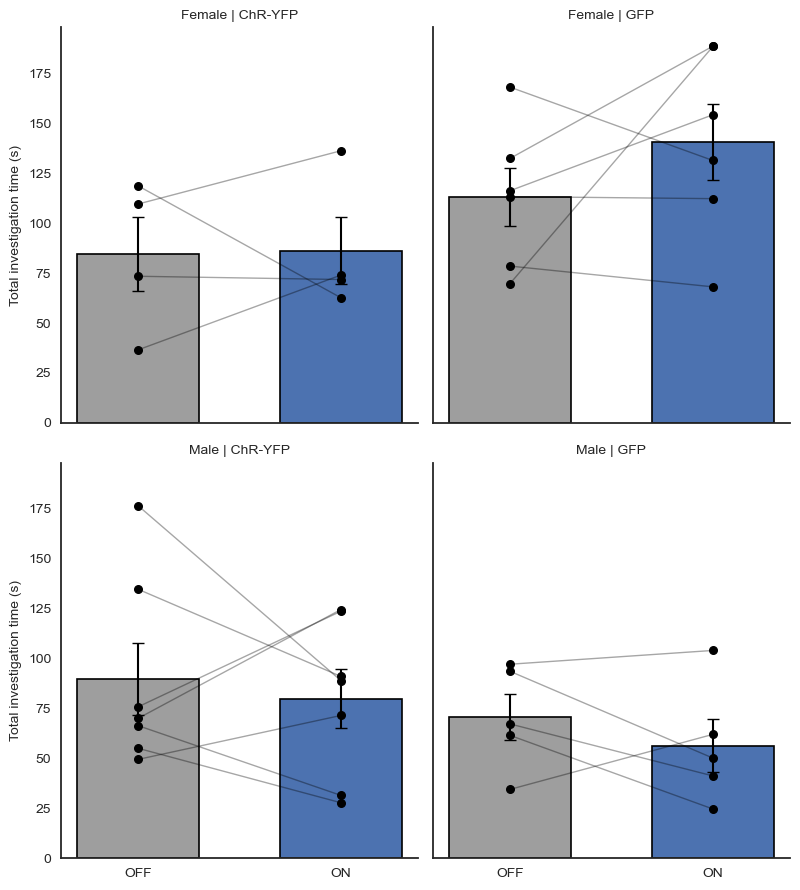

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import sem

sns.set_style("white")

palette_laser = {
    "OFF": "#9E9E9E",
    "ON": "#4C72B0"
}

laser_order = ["OFF", "ON"]

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def bar_with_pairs(data, **kwargs):
    ax = plt.gca()

    # --- Compute means + SEM ---
    means = []
    errors = []

    for laser in laser_order:
        vals = data[data["Laser"] == laser]["InvestigationTime"]
        means.append(vals.mean())
        errors.append(sem(vals))

    # --- Plot bars ---
    x = np.arange(len(laser_order))

    ax.bar(
        x,
        means,
        yerr=errors,
        capsize=4,
        color=[palette_laser[l] for l in laser_order],
        edgecolor="black",
        linewidth=1.2,
        width=0.6,
        zorder=1
    )

    # --- Overlay paired lines ---
    for subject, df_sub in data.groupby("SubjectID"):

        if set(df_sub["Laser"]) == set(laser_order):
            df_sub = df_sub.set_index("Laser").loc[laser_order]

            ax.plot(
                x,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.35,
                linewidth=1,
                zorder=3
            )

            ax.scatter(
                x,
                df_sub["InvestigationTime"],
                color="black",
                s=30,
                zorder=4
            )

    # --- Clean styling ---
    ax.set_xticks(x)
    ax.set_xticklabels(laser_order)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)
    ax.tick_params(width=1.2)

g.map_dataframe(bar_with_pairs)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.tight_layout()
plt.show()


| MOE     | Laser | Interpretation                         |
| ------- | ----- | -------------------------------------- |
| Intact  | OFF   | Normal baseline                        |
| Intact  | ON    | Artificial BLA drive                   |
| Ablated | OFF   | Sensory loss only                      |
| Ablated | ON    | Artificial drive without sensory input |
This is a 2×2 factorial design.

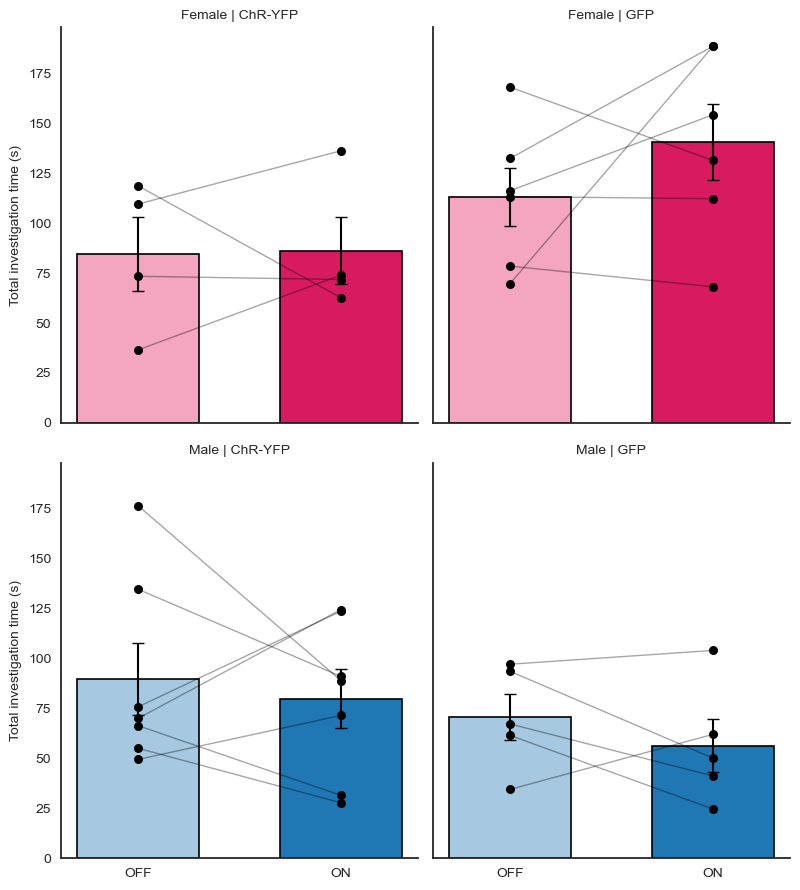

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import sem

sns.set_style("white")

laser_order = ["OFF", "ON"]

# --- Sex-specific color palettes ---
sex_palette = {
    "Female": {
        "OFF": "#F4A6C1",   # light pink
        "ON":  "#D81B60"    # darker pink
    },
    "Male": {
        "OFF": "#A6C8E0",   # light blue
        "ON":  "#1F77B4"    # darker blue
    }
}

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def bar_with_pairs(data, **kwargs):
    ax = plt.gca()

    sex = data["SubjSex"].iloc[0]  # get sex for this panel

    means = []
    errors = []

    for laser in laser_order:
        vals = data[data["Laser"] == laser]["InvestigationTime"]
        means.append(vals.mean())
        errors.append(sem(vals))

    x = np.arange(len(laser_order))

    # --- Bars colored by sex ---
    ax.bar(
        x,
        means,
        yerr=errors,
        capsize=4,
        color=[sex_palette[sex][l] for l in laser_order],
        edgecolor="black",
        linewidth=1.2,
        width=0.6,
        zorder=1
    )

    # --- Paired lines ---
    for subject, df_sub in data.groupby("SubjectID"):
        if set(df_sub["Laser"]) == set(laser_order):
            df_sub = df_sub.set_index("Laser").loc[laser_order]

            ax.plot(
                x,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.35,
                linewidth=1,
                zorder=3
            )

            ax.scatter(
                x,
                df_sub["InvestigationTime"],
                color="black",
                s=30,
                zorder=4
            )

    # --- Clean styling ---
    ax.set_xticks(x)
    ax.set_xticklabels(laser_order)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)
    ax.tick_params(width=1.2)

g.map_dataframe(bar_with_pairs)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_36704\1741318957.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for subject, df_sub in data.groupby("SubjectID"):
C:\Users\sjs93\AppData\Local\Temp\ipykernel_36704\1741318957.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for subject, df_sub in data.groupby("SubjectID"):
C:\Users\sjs93\AppData\Local\Temp\ipykernel_36704\1741318957.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silenc

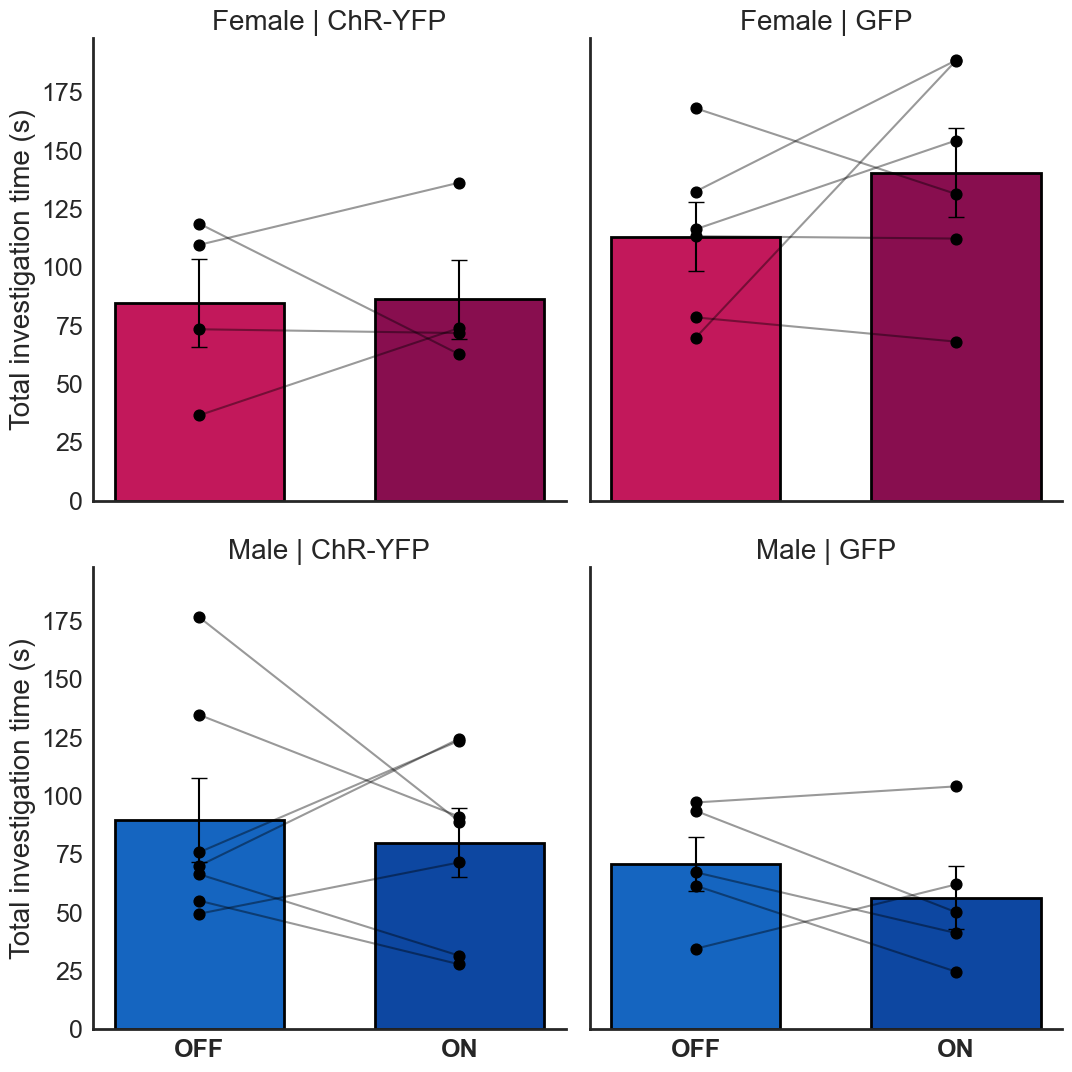

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import sem

# --------------------------------------------------
# CLEAN SCIENTIFIC STYLE
# --------------------------------------------------

sns.set_style("white")
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
})

laser_order = ["OFF", "ON"]

# --------------------------------------------------
# Stronger, less pastel colors
# --------------------------------------------------

sex_palette = {
    "Female": {
        "OFF": "#C2185B",   # deep magenta
        "ON":  "#880E4F"    # darker magenta
    },
    "Male": {
        "OFF": "#1565C0",   # strong blue
        "ON":  "#0D47A1"    # darker blue
    }
}

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=5.5,
    aspect=1.0
)

def bar_with_pairs(data, **kwargs):
    ax = plt.gca()
    sex = data["SubjSex"].iloc[0]

    means = []
    errors = []

    for laser in laser_order:
        vals = data[data["Laser"] == laser]["InvestigationTime"]
        means.append(vals.mean())
        errors.append(sem(vals))

    x = np.arange(len(laser_order))

    # --- Thicker bars ---
    ax.bar(
        x,
        means,
        yerr=errors,
        capsize=6,
        color=[sex_palette[sex][l] for l in laser_order],
        edgecolor="black",
        linewidth=2,
        width=0.65,
        zorder=1
    )

    # --- Paired lines ---
    for subject, df_sub in data.groupby("SubjectID"):
        if set(df_sub["Laser"]) == set(laser_order):
            df_sub = df_sub.set_index("Laser").loc[laser_order]

            ax.plot(
                x,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1.5,
                zorder=3
            )

            ax.scatter(
                x,
                df_sub["InvestigationTime"],
                color="black",
                s=60,
                zorder=4
            )

    # --- Axis formatting ---
    ax.set_xticks(x)
    ax.set_xticklabels(laser_order, fontsize=18, fontweight="bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(width=2)

g.map_dataframe(bar_with_pairs)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.tight_layout()
plt.show()

In [119]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Make sure categorical variables are set correctly
invest_plot["SubjSex"] = invest_plot["SubjSex"].astype("category")
invest_plot["Group"] = invest_plot["Group"].astype("category")
invest_plot["Laser"] = invest_plot["Laser"].astype("category")
invest_plot["SubjectID"] = invest_plot["SubjectID"].astype("category")

# Linear mixed model
model = smf.mixedlm(
    "InvestigationTime ~ SubjSex * Group * Laser",
    data=invest_plot,
    groups=invest_plot["SubjectID"]
)

result = model.fit()

print(result.summary())


                         Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         InvestigationTime
No. Observations:         44              Method:                     REML             
No. Groups:               22              Scale:                      1143.9615        
Min. group size:          2               Log-Likelihood:             -188.9363        
Max. group size:          2               Converged:                  Yes              
Mean group size:          2.0                                                          
---------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z|  [0.025   0.975]
---------------------------------------------------------------------------------------
Intercept                                 84.570   19.368  4.366 0.000   46.609 122.531
SubjSex[T.Male]                            5.170   24.279

In [120]:
delta = invest_plot.pivot_table(
    index=["SubjectID", "SubjSex", "Group"],
    columns="Laser",
    values="InvestigationTime"
).reset_index()

delta["Delta"] = delta["ON"] - delta["OFF"]

print(delta.groupby(["SubjSex", "Group"])["Delta"].mean())
print(delta.groupby(["SubjSex", "Group"])["Delta"].std())


SubjSex  Group  
Female   ChR-YFP     1.612000
         GFP        27.467167
Male     ChR-YFP    -9.862714
         GFP       -14.377000
Name: Delta, dtype: float64
SubjSex  Group  
Female   ChR-YFP    41.825698
         GFP        55.911301
Male     ChR-YFP    52.612050
         GFP        30.398678
Name: Delta, dtype: float64


C:\Users\sjs93\AppData\Local\Temp\ipykernel_36704\503093368.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  delta = invest_plot.pivot_table(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_36704\503093368.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(delta.groupby(["SubjSex", "Group"])["Delta"].mean())
C:\Users\sjs93\AppData\Local\Temp\ipykernel_36704\503093368.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(delta.groupby(["S

In [121]:
delta.sort_values("Delta")


Laser,SubjectID,SubjSex,Group,OFF,ON,Delta
16,7_2,Male,ChR-YFP,176.582,88.995,-87.587
1,1_2,Female,ChR-YFP,118.716,62.666,-56.050
17,7_3,Male,ChR-YFP,134.726,91.073,-43.653
18,8_1,Male,GFP,93.618,50.169,-43.449
14,6_3,Male,GFP,61.533,24.682,-36.851
8,4_2,Female,GFP,168.121,131.392,-36.729
11,5_2,Male,ChR-YFP,66.427,31.501,-34.926
12,5_3,Male,ChR-YFP,55.085,27.810,-27.275
19,8_2,Male,GFP,67.269,41.240,-26.029
3,2_2,Female,GFP,78.518,68.124,-10.394


In [122]:
invest_plot.groupby(["SubjSex","Group","Laser"])["InvestigationTime"].mean()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_36704\35360708.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  invest_plot.groupby(["SubjSex","Group","Laser"])["InvestigationTime"].mean()


SubjSex  Group    Laser
Female   ChR-YFP  OFF       84.570250
                  ON        86.182250
         GFP      OFF      113.071500
                  ON       140.538667
Male     ChR-YFP  OFF       89.740000
                  ON        79.877286
         GFP      OFF       70.818800
                  ON        56.441800
Name: InvestigationTime, dtype: float64

In [123]:
invest_plot.groupby(["SubjSex","Group"])["SubjectID"].nunique()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_36704\433119113.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  invest_plot.groupby(["SubjSex","Group"])["SubjectID"].nunique()


SubjSex  Group  
Female   ChR-YFP    4
         GFP        6
Male     ChR-YFP    7
         GFP        5
Name: SubjectID, dtype: int64